### Introduction: The Cell Object

This notebook serves as an introduction to this library. It demonstrates the usage and structure of the central `Cell` class in this library. As the name suggests, it models the electrical behavior of a battery cell. The exact implementation can be found in `pcebatt/core/cell`.

The `Cell` object allows you to configure different types of stochastic and deterministic models and simulate them.

By the end of this introduction, you will know how to instantiate, configure, and run simulations using this class.

In [5]:
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# setup paths for relative imports
sys.path.append(os.path.abspath(".."))
from pcebatt.utils import load_validation # import validation profile
from pcebatt.core import Cell

### Different Ways to Instantiate `Cell`

Let us take a closer look at the class definition:

```python
class Cell:
    def __init__(
        self,
        capacity: float,
        initial_soc: float,
        initial_soc_unc: float = 1e-3,
        capacity_unc: float = 1e-3,
        config=None,
        load_default_config=True,
    ):
```

As we can see, the `Cell` object requires a `capacity` parameter and an initial state-of-charge (`initial_soc`) estimate, which may itself be uncertain.

In general, simulating the cell yields two arrays for the voltage:
- the mean voltage, and  
- the associated uncertainty.

These two outputs are returned regardless of whether the chosen model is deterministic or stochastic. In the deterministic case, the uncertainty array is simply filled with zeros, but it is still returned for consistency.

For this reason, the `Cell` class assigns a small default uncertainty to `initial_soc`. Additionally, a capacity uncertainty parameter (`capacity_unc`) can also be specified.

In [6]:
cell = Cell(capacity=2.5, initial_soc=0.95)

[Cell] No configuration path specified. Loading defaults...


By default, the `Cell` object reads from the standard model configuration file [`pcebatt/config/cfg.yaml`](../pcebatt/config/cfg.yaml).

Within the `Cell`, an object from the `BatteryModel` class handles the aggregation of different submodels, each representing a specific aspect of the battery’s behavior. The implementation can be found here: [`pcebatt/models/composite/battery_model.py`](../pcebatt/models/composite/battery_model.py)

To inspect which models are currently configured within a `Cell` instance, you can do the following:

In [7]:
cell.get_model_dict()

{'ecm': <pcebatt.models.submodels.ecm.GalerkinPCE at 0x2114bcd2660>,
 'ocv': <pcebatt.models.submodels.ocv.qOCV_Differential at 0x2114e0d1f90>,
 'hysteresis': <pcebatt.models.submodels.hysteresis.Plett_Hysteresis at 0x2114e0d2710>}

Here we can see that, by default, the `Cell` is initialized with an ECM submodel, an OCV submodel, and a hysteresis submodel. Each of these reacts independently to the input (current), and their results are then superposed. The total variance is computed as the root-sum-square of the individual variances.

You can pass your own configuration file into the constructor, however the fields must be identical to the ones found in default config. For the purposes of this example, I have created a dummy configuration file in the same directory as this notebook: 

In [8]:
config_path = "./dummy_config.yaml"

cell = Cell(capacity=2.5, initial_soc=0.95, config=config_path)

print("\nHere are the currently loaded models:")
cell.get_model_dict()

print("\nCurrent config path:")
cfg_path, cfg_dict = cell.get_current_config()
print(cfg_path)
print("\nand the config dictionary:")
cfg_dict

[Cell] Loading configuration from ./dummy_config.yaml

Here are the currently loaded models:

Current config path:
C:\Users\aregm\Desktop\pmb\examples\dummy_config.yaml

and the config dictionary:


{'defaults': {'logger_level': 'ERROR'},
 'models': [{'class': 'nRC',
   'module': 'pcebatt.models.submodels.ecm',
   'kwargs': {'logger_level': 'ERROR'}}],
 'simulation': {'temperatures': [15, 25, 35, 45],
  'paths': {'parameters': {'dist_folder': '../pcebatt/data/distributions',
    'file_naming_scheme': '{temp}deg.parquet',
    'param_labels': ['mu_R0',
     'sigma_R0',
     'mu_tau1_inv',
     'sigma_tau1_inv',
     'mu_c1_inv',
     'sigma_c1_inv',
     'mu_tau2_inv',
     'sigma_tau2_inv',
     'mu_c2_inv',
     'sigma_c2_inv']},
   'ocv': {'ocv_folder': '../pcebatt/data/measurements/qocv20',
    'file_naming_scheme': {'charge': 'qocv_{temp}deg_charge.parquet',
     'discharge': 'qocv_{temp}deg_discharge.parquet'}},
   'validation': {'validation_path': '../pcebatt/data/measurements/validation'}}}}

Upon inspecting the `dummy_configuration` file, you may have noticed a field called `simulation`. This field specifies all relevant information about the available parametrization data, including its structure and storage locations. You can find more details about these configurations in the notebooks dedicated to the individual model types (e.g., ECM, OCV, etc.).

The `Cell` class also allows you to load and configure the respective submodels manually. To do so, set the `load_default_config` parameter to `False` and add the respective model instance with the setter method, as shown below. Note, however, that some data-driven submodels, such as `Galerkin_PCE`, require information about where to fetch their data from. In such cases, you must provide a configuration dictionary when initializing them. Otherwise, they will fall back to the default data located in [`pcebatt/data`](../pcebatt/data/).

In [9]:
cell = Cell(capacity=2.5, initial_soc=0.95, load_default_config=False)

from pcebatt.models.submodels.ecm import GalerkinPCE
cell.set_model(GalerkinPCE()) # default config will be loaded
print(cell.get_model_dict())

[Cell] Initializing empty cell model.
{'ecm': <pcebatt.models.submodels.ecm.GalerkinPCE object at 0x000002114BCD2660>}


### Simulating the `Cell`

Having covered instantiation, we can now move on to simulating the `Cell`. We begin by loading the default validation profile and initializing the cell object:

In [10]:
time, current, voltage, soc, temperature, C_nom, C_nom_unc = load_validation(short=False)
cell_params = dict(initial_soc=soc[0], capacity=C_nom, capacity_unc=C_nom*C_nom_unc)
cell = Cell(**cell_params) # defaults settings used here

[Cell] No configuration path specified. Loading defaults...


Let us visualize the loaded current and voltage sequence:

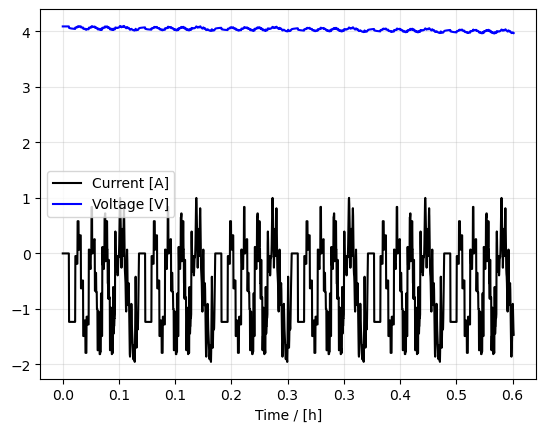

In [11]:
fig, ax = plt.subplots()
ix = [i for i in range(2000)]
ax.plot(time[ix], current[ix], c='black', label='Current [A]')
ax.plot(time[ix], voltage[0][ix], c='b', label='Voltage [V]') # voltage is a tuple (mean_array, std_array)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/3600:.1f}'))
ax.set_xlabel('Time / [h]')
ax.grid(True, alpha=0.3)
plt.legend()
plt.show()

The `Cell` can now be simulated by running its `solve` method:

In [12]:
cell.solve(current=current, time=time, temperature=temperature)

Progress: |██████████████████████████████| 100%


We can now visualize the simulation output and compare it against the ground truth using the utility functions included in the library:

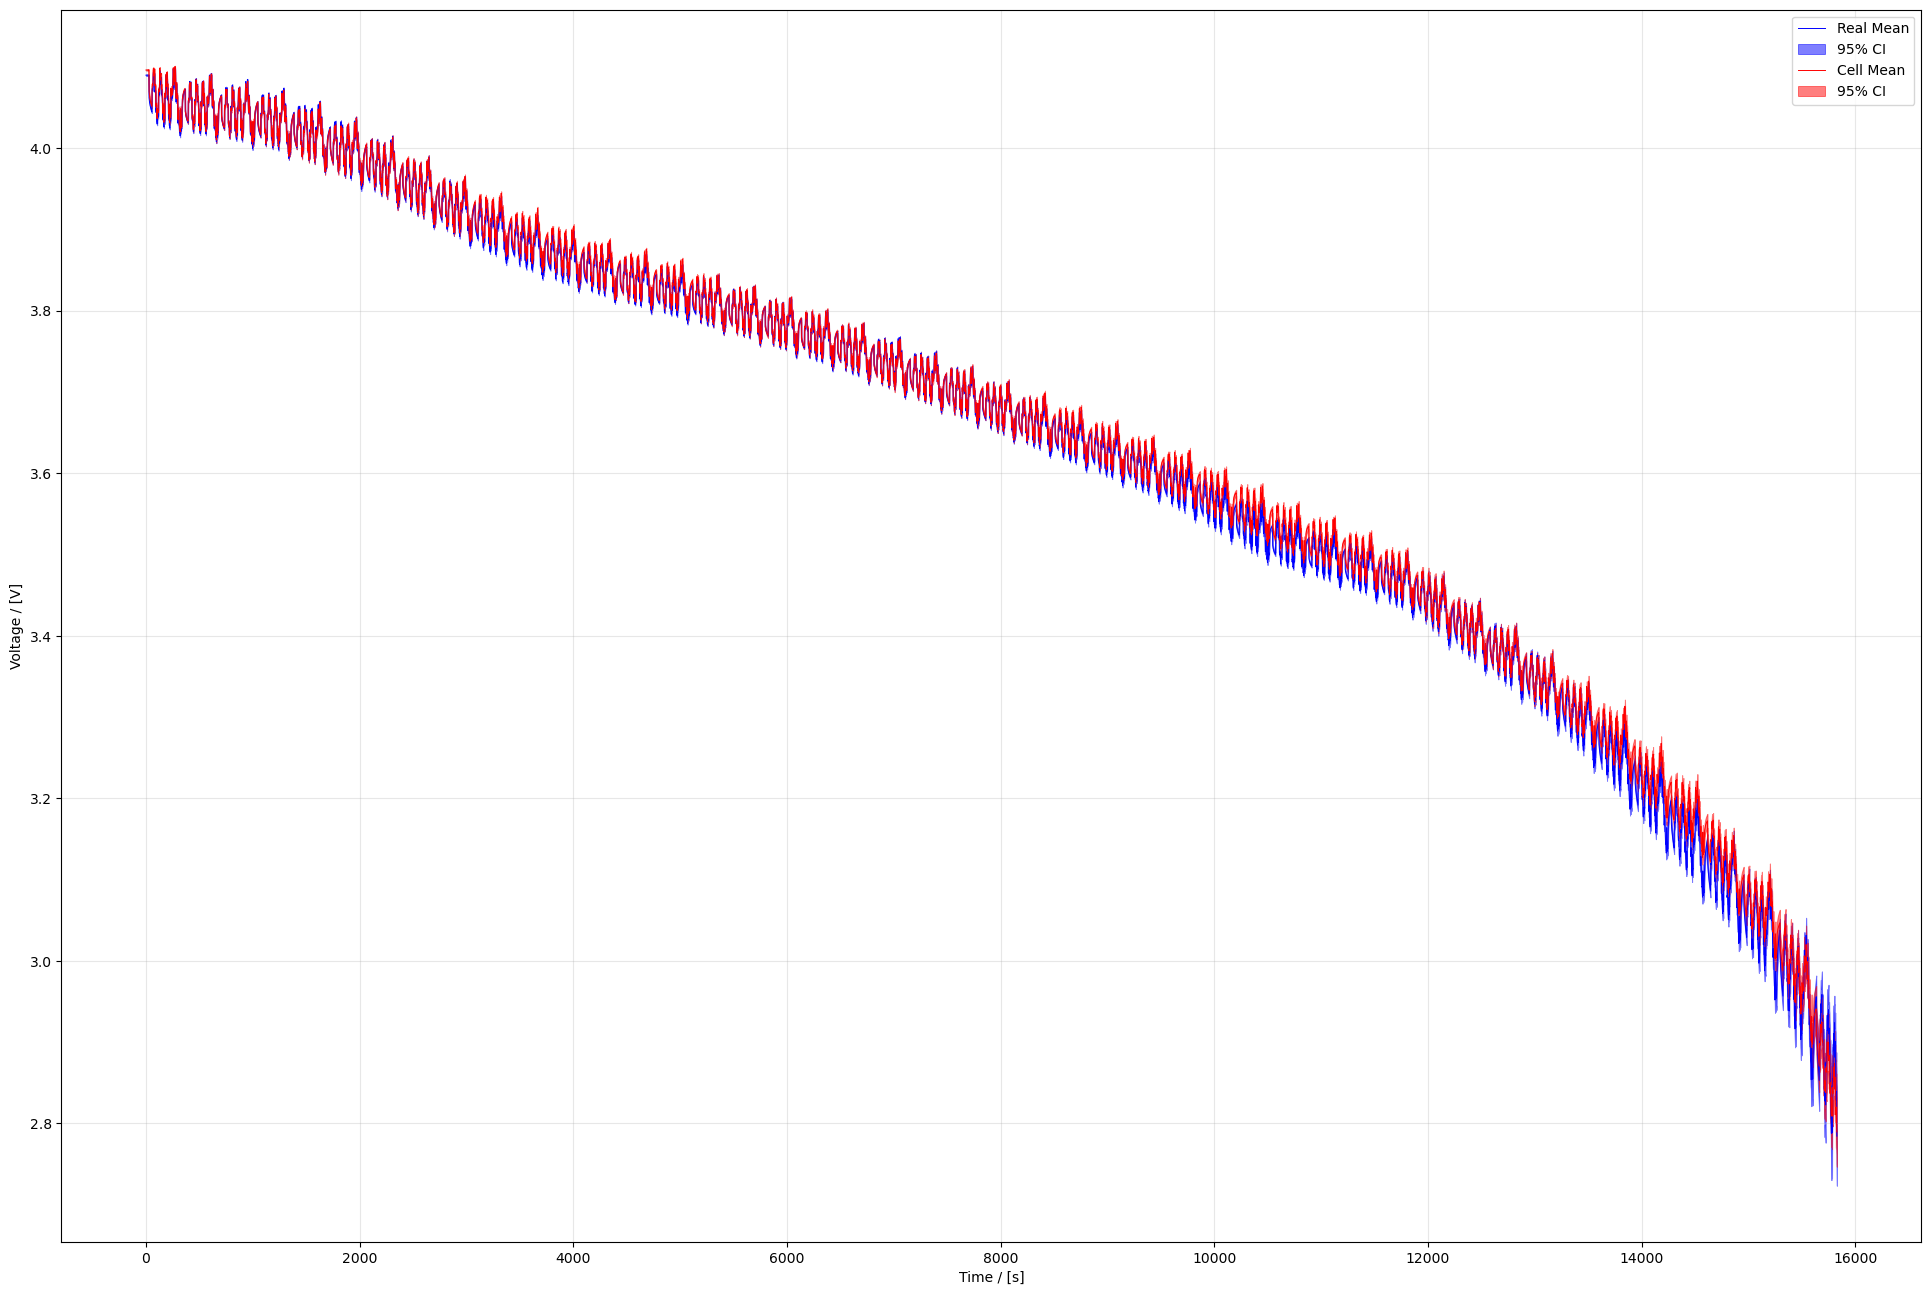

In [13]:
from pcebatt.utils import add_trace, RMSE

fig, ax = plt.subplots(figsize = (24, 16))
add_trace(ax, time, voltage[0], voltage[1], c='b', legend=['Real Mean', '95% CI'])
add_trace(ax, time, cell.voltage.mean, cell.voltage.std, c='r', legend=['Cell Mean', '95% CI'])
ax.legend(loc = 'upper right')
ax.set_xlabel('Time / [s]')
ax.set_ylabel('Voltage / [V]')
ax.grid(True, alpha = 0.3)
plt.show()

RMSE: 11.40 mV
STD RMSE: 0.75 mV


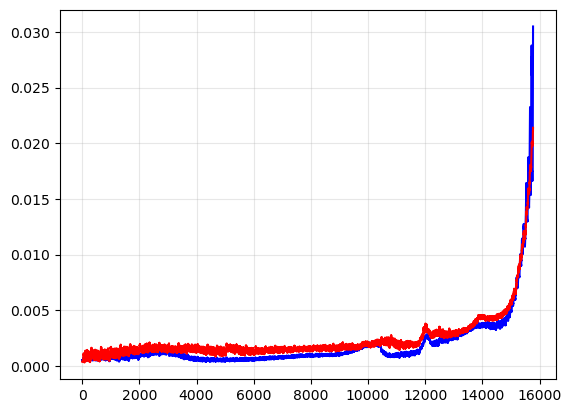

In [14]:
# Detailed comparison
print(f"RMSE: {1000*RMSE(cell.voltage.mean, voltage[0]):.2f} mV")
print(f"STD RMSE: {1000*RMSE(cell.voltage.std, voltage[1]):.2f} mV")
fig, ax = plt.subplots()
ax.plot(voltage[1], c='b', label='Measured Std.')
ax.plot(cell.voltage.std, c='r', label='Cell Std.')
ax.grid(True, alpha=0.3)
plt.show()

That concludes the notebook. Happy tinkering!